In [ ]:
from google.colab import drive
drive.mount('/content/drive',)

Mounted at /content/drive


In [ ]:
import os

PROJECT_DIR = "/content/drive/MyDrive/Deepfake_Project"
RAW_DIR = os.path.join(PROJECT_DIR, "data/raw/dfdc_train_part_00")
PROCESSED_DIR = os.path.join(PROJECT_DIR, "data/processed")

CSV_DIR = os.path.join(PROCESSED_DIR, "csv")
FRAMES_DIR = os.path.join(PROCESSED_DIR, "frames")
AUDIO_DIR = os.path.join(PROCESSED_DIR, "audio")
TEXT_DIR = os.path.join(PROCESSED_DIR, "text")

OUTPUT_DIR = os.path.join(PROJECT_DIR, "data/outputs")
MODEL_DIR = os.path.join(OUTPUT_DIR, "models")
GRAPH_DIR = os.path.join(OUTPUT_DIR, "graphs")
REPORT_DIR = os.path.join(OUTPUT_DIR, "reports")
PRED_DIR = os.path.join(OUTPUT_DIR, "predictions")
EXPLAIN_DIR = os.path.join(OUTPUT_DIR, "explainability")
UNCERTAIN_DIR = os.path.join(OUTPUT_DIR, "uncertain_samples")

for folder in [CSV_DIR, FRAMES_DIR, AUDIO_DIR, TEXT_DIR, MODEL_DIR, GRAPH_DIR, REPORT_DIR, PRED_DIR, EXPLAIN_DIR, UNCERTAIN_DIR]:
    os.makedirs(folder, exist_ok=True)

print("All folders are ready.")

All folders are ready.


In [ ]:
!pip install opencv-python tensorflow scikit-learn pandas matplotlib seaborn tqdm moviepy librosa soundfile

In [ ]:
import os
import json
import pandas as pd

metadata_path = os.path.join(RAW_DIR, "metadata.json")

with open(metadata_path, "r") as f:
    metadata = json.load(f)

df = pd.DataFrame.from_dict(metadata, orient="index")
df.reset_index(inplace=True)
df.rename(columns={"index": "filename"}, inplace=True)

df["video_path"] = df["filename"].apply(lambda x: os.path.join(RAW_DIR, x))

print(df.head())
print(df.columns)
print(df["label"].value_counts())

         filename label  split        original  \
0  owxbbpjpch.mp4  FAKE  train  wynotylpnm.mp4   
1  vpmyeepbep.mp4  REAL  train             NaN   
2  fzvpbrzssi.mp4  REAL  train             NaN   
3  htorvhbcae.mp4  FAKE  train  wclvkepakb.mp4   
4  fckxaqjbxk.mp4  FAKE  train  vpmyeepbep.mp4   

                                          video_path  
0  /content/drive/MyDrive/Deepfake_Project/data/r...  
1  /content/drive/MyDrive/Deepfake_Project/data/r...  
2  /content/drive/MyDrive/Deepfake_Project/data/r...  
3  /content/drive/MyDrive/Deepfake_Project/data/r...  
4  /content/drive/MyDrive/Deepfake_Project/data/r...  
Index(['filename', 'label', 'split', 'original', 'video_path'], dtype='object')
label
FAKE    1248
REAL      86
Name: count, dtype: int64


In [ ]:
metadata_csv = os.path.join(CSV_DIR, "metadata_part00.csv")
df.to_csv(metadata_csv, index=False)
print("Saved:", metadata_csv)

Saved: /content/drive/MyDrive/Deepfake_Project/data/processed/csv/metadata_part00.csv


In [ ]:
real_df = df[df["label"] == "REAL"].sample(80, random_state=42)
fake_df = df[df["label"] == "FAKE"].sample(80, random_state=42)

sample_df = pd.concat([real_df, fake_df]).sample(frac=1, random_state=42).reset_index(drop=True)

sample_csv = os.path.join(CSV_DIR, "sample_160_videos.csv")
sample_df.to_csv(sample_csv, index=False)

print(sample_df["label"].value_counts())
print("Total videos:", len(sample_df))
print("Saved:", sample_csv)
sample_df.head()

label
FAKE    80
REAL    80
Name: count, dtype: int64
Total videos: 160
Saved: /content/drive/MyDrive/Deepfake_Project/data/processed/csv/sample_160_videos.csv


,filename,label,split,original,video_path
0,kxhwssipyi.mp4,FAKE,train,sttnfyptum.mp4,/content/drive/MyDrive/Deepfake_Project/data/r...
1,ratscdfvdk.mp4,FAKE,train,ddtbarpcgo.mp4,/content/drive/MyDrive/Deepfake_Project/data/r...
2,lxnqzocgaq.mp4,FAKE,train,xjzkfqddyk.mp4,/content/drive/MyDrive/Deepfake_Project/data/r...
3,xchzardbfa.mp4,REAL,train,NaN,/content/drive/MyDrive/Deepfake_Project/data/r...
4,iocjgjemeb.mp4,FAKE,train,sttnfyptum.mp4,/content/drive/MyDrive/Deepfake_Project/data/r...


In [ ]:
import cv2
from tqdm import tqdm

def extract_frames(video_path, save_dir, num_frames=5):
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        cap.release()
        return 0

    frame_indices = sorted(set([int(i * total_frames / num_frames) for i in range(num_frames)]))
    saved = 0
    current_idx = 0
    target_set = set(frame_indices)

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if current_idx in target_set:
            frame_name = f"frame_{current_idx}.jpg"
            cv2.imwrite(os.path.join(save_dir, frame_name), frame)
            saved += 1

        current_idx += 1

    cap.release()
    return saved

for _, row in tqdm(sample_df.iterrows(), total=len(sample_df)):
    filename = row["filename"]
    label = row["label"]
    video_path = row["video_path"]

    video_name = os.path.splitext(filename)[0]
    save_dir = os.path.join(FRAMES_DIR, label, video_name)
    os.makedirs(save_dir, exist_ok=True)

    try:
        extract_frames(video_path, save_dir, num_frames=5)
    except Exception as e:
        print("Error:", filename, e)

print("Frame extraction finished.")

100%|██████████| 160/160 [12:42<00:00,  4.76s/it]

Frame extraction finished.


In [ ]:
image_rows = []

for _, row in sample_df.iterrows():
    filename = row["filename"]
    label = row["label"]

    video_name = os.path.splitext(filename)[0]
    frame_dir = os.path.join(FRAMES_DIR, label, video_name)

    if os.path.exists(frame_dir):
        for img in os.listdir(frame_dir):
            if img.endswith(".jpg"):
                image_rows.append({
                    "filename": filename,
                    "label": label,
                    "image_path": os.path.join(frame_dir, img)
                })

image_df = pd.DataFrame(image_rows)

image_csv = os.path.join(CSV_DIR, "image_dataset.csv")
image_df.to_csv(image_csv, index=False)

print(image_df.head())
print(image_df["label"].value_counts())
print("Total images:", len(image_df))
print("Saved:", image_csv)

         filename label                                         image_path
0  kxhwssipyi.mp4  FAKE  /content/drive/MyDrive/Deepfake_Project/data/p...
1  kxhwssipyi.mp4  FAKE  /content/drive/MyDrive/Deepfake_Project/data/p...
2  kxhwssipyi.mp4  FAKE  /content/drive/MyDrive/Deepfake_Project/data/p...
3  kxhwssipyi.mp4  FAKE  /content/drive/MyDrive/Deepfake_Project/data/p...
4  kxhwssipyi.mp4  FAKE  /content/drive/MyDrive/Deepfake_Project/data/p...
label
FAKE    400
REAL    400
Name: count, dtype: int64
Total images: 800
Saved: /content/drive/MyDrive/Deepfake_Project/data/processed/csv/image_dataset.csv


In [ ]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    image_df,
    test_size=0.2,
    stratify=image_df["label"],
    random_state=42
)

print("Train:")
print(train_df["label"].value_counts())

print("Validation:")
print(val_df["label"].value_counts())

Train:
label
FAKE    320
REAL    320
Name: count, dtype: int64
Validation:
label
REAL    80
FAKE    80
Name: count, dtype: int64


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 16

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col="image_path",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

val_gen = val_datagen.flow_from_dataframe(
    val_df,
    x_col="image_path",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

print(train_gen.class_indices)

Found 640 validated image filenames belonging to 2 classes.
Found 160 validated image filenames belonging to 2 classes.
{'FAKE': 0, 'REAL': 1}


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)

output = Dense(1, activation="sigmoid")(x)

visual_model = Model(inputs=base_model.input, outputs=output)

visual_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

visual_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
history = visual_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 623s 15s/step - accuracy: 0.5156 - loss: 0.8278 - val_accuracy: 0.6438 - val_loss: 0.6484
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 18s 445ms/step - accuracy: 0.5469 - loss: 0.7966 - val_accuracy: 0.7188 - val_loss: 0.5921
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 18s 450ms/step - accuracy: 0.5750 - loss: 0.7560 - val_accuracy: 0.7437 - val_loss: 0.5938
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 17s 437ms/step - accuracy: 0.5828 - loss: 0.7148 - val_accuracy: 0.7375 - val_loss: 0.5850
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 18s 446ms/step - accuracy: 0.6156 - loss: 0.7015 - val_accuracy: 0.7312 - val_loss: 0.5945
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 18s 441ms/step - accuracy: 0.6375 - loss: 0.6566 - val_accuracy: 0.7563 - val_loss: 0.5894
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 18s 441ms/step - accuracy: 0.6250 - loss: 0.6637 - val_accuracy: 0.7375 - val_loss: 0.5879
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 18s 446ms/step - accuracy: 0.6359 - loss: 0.6600 - val_accur

In [ ]:
visual_model_path = os.path.join(MODEL_DIR, "visual_mobilenetv2_model.keras")
visual_model.save(visual_model_path)

print("Saved:", visual_model_path)

Saved: /content/drive/MyDrive/Deepfake_Project/data/outputs/models/visual_mobilenetv2_model.keras


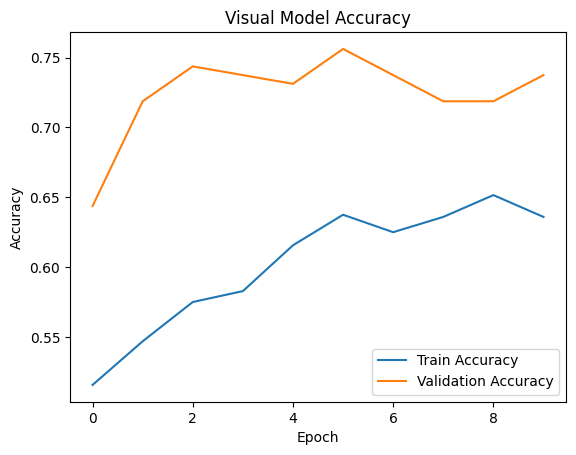

Saved: /content/drive/MyDrive/Deepfake_Project/data/outputs/graphs/visual_accuracy_graph.png


In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Visual Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

graph_path = os.path.join(GRAPH_DIR, "visual_accuracy_graph.png")
plt.savefig(graph_path)
plt.show()

print("Saved:", graph_path)

In [ ]:
!pip install -q moviepy librosa soundfile openai-whisper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 47.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
from moviepy.editor import VideoFileClip
from tqdm import tqdm

audio_records = []

for _, row in tqdm(sample_df.iterrows(), total=len(sample_df)):
    filename = row["filename"]
    label = row["label"]
    video_path = row["video_path"]

    out_dir = os.path.join(AUDIO_DIR, label)
    os.makedirs(out_dir, exist_ok=True)

    audio_path = os.path.join(out_dir, os.path.splitext(filename)[0] + ".wav")

    status = "not_extracted"

    try:
        if os.path.exists(audio_path):
            status = "already_exists"
        else:
            clip = VideoFileClip(video_path)
            if clip.audio is not None:
                clip.audio.write_audiofile(audio_path, logger=None)
                status = "extracted"
            else:
                status = "no_audio"
            clip.close()
    except Exception as e:
        status = "error"

    audio_records.append({
        "filename": filename,
        "label": label,
        "audio_path": audio_path,
        "audio_status": status
    })

audio_df = pd.DataFrame(audio_records)
audio_csv = os.path.join(CSV_DIR, "audio_extraction_summary.csv")
audio_df.to_csv(audio_csv, index=False)

print(audio_df["audio_status"].value_counts())
print("Saved:", audio_csv)

/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:294: SyntaxWarning: invalid escape sequence '\d'
  lines_video = [l for l in lines if ' Video: ' in l and re.search('\d+x\d+', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:367: SyntaxWarning: invalid escape sequence '\d'
  rotation_lines = [l for l in lines if 'rotate          :' in l and re.search('\d+$', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:370: SyntaxWarning: invalid escape sequence '\d'
  match = re.search('\d+$', rotation_line)
  if event.key is 'enter':

100%|██████████| 160/160 [00:00<00:00, 163.84it/s]

audio_status
already_exists    160
Name: count, dtype: int64
Saved: /content/drive/MyDrive/Deepfake_Project/data/processed/csv/audio_extraction_summary.csv


In [ ]:
import whisper

whisper_model = whisper.load_model("base")

100%|████████████████████████████████████████| 139M/139M [00:00<00:00, 178MiB/s]


In [ ]:
text_rows = []

for _, row in tqdm(audio_df.iterrows(), total=len(audio_df)):
    filename = row["filename"]
    label = row["label"]
    audio_path = row["audio_path"]

    transcript = ""

    if os.path.exists(audio_path):
        try:
            result = whisper_model.transcribe(audio_path)
            transcript = result["text"]
        except Exception as e:
            transcript = ""

    text_rows.append({
        "filename": filename,
        "label": label,
        "audio_path": audio_path,
        "transcript": transcript
    })

text_df = pd.DataFrame(text_rows)

text_csv = os.path.join(TEXT_DIR, "text_features_whisper.csv")
text_df.to_csv(text_csv, index=False)

print(text_df.head())
print("Saved:", text_csv)

100%|██████████| 160/160 [03:18<00:00,  1.24s/it]


         filename label                                         audio_path  \
0  kxhwssipyi.mp4  FAKE  /content/drive/MyDrive/Deepfake_Project/data/p...   
1  ratscdfvdk.mp4  FAKE  /content/drive/MyDrive/Deepfake_Project/data/p...   
2  lxnqzocgaq.mp4  FAKE  /content/drive/MyDrive/Deepfake_Project/data/p...   
3  xchzardbfa.mp4  REAL  /content/drive/MyDrive/Deepfake_Project/data/p...   
4  iocjgjemeb.mp4  FAKE  /content/drive/MyDrive/Deepfake_Project/data/p...   

                                          transcript  
0   less than a little bit harder than other peop...  
1   I don't even know what half of them are anymo...  
2   Why do we need art? Well, we need art for so ...  
3   R.I. has changed in a lot of ways with techno...  
4   less than a little bit harder than other peop...  
Saved: /content/drive/MyDrive/Deepfake_Project/data/processed/text/text_features_whisper.csv


In [ ]:
import librosa
import numpy as np

def extract_mfcc(audio_path):
    try:
        y, sr = librosa.load(audio_path, sr=16000)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        return np.mean(mfcc, axis=1)
    except:
        return np.zeros(13)

In [ ]:
audio_feature_rows = []

for _, row in tqdm(audio_df.iterrows(), total=len(audio_df)):
    features = extract_mfcc(row["audio_path"])

    record = {
        "filename": row["filename"],
        "label": row["label"],
        "audio_path": row["audio_path"]
    }

    for i, value in enumerate(features):
        record[f"mfcc_{i+1}"] = value

    audio_feature_rows.append(record)

audio_features_df = pd.DataFrame(audio_feature_rows)

audio_features_csv = os.path.join(CSV_DIR, "audio_features_mfcc.csv")
audio_features_df.to_csv(audio_features_csv, index=False)

print(audio_features_df.head())
print("Saved:", audio_features_csv)

100%|██████████| 160/160 [00:18<00:00,  8.52it/s]

         filename label                                         audio_path  \
0  kxhwssipyi.mp4  FAKE  /content/drive/MyDrive/Deepfake_Project/data/p...   
1  ratscdfvdk.mp4  FAKE  /content/drive/MyDrive/Deepfake_Project/data/p...   
2  lxnqzocgaq.mp4  FAKE  /content/drive/MyDrive/Deepfake_Project/data/p...   
3  xchzardbfa.mp4  REAL  /content/drive/MyDrive/Deepfake_Project/data/p...   
4  iocjgjemeb.mp4  FAKE  /content/drive/MyDrive/Deepfake_Project/data/p...   

       mfcc_1     mfcc_2     mfcc_3     mfcc_4     mfcc_5     mfcc_6  \
0 -410.739166  96.866005  -7.448000  17.368610 -10.510450 -14.920521   
1 -463.254791  91.861320  -4.841594  15.173533 -13.326157  -2.756058   
2 -477.235809  93.086708  34.393509  34.861996   9.857111   0.469814   
3 -459.674927  99.065720  21.345388  23.941250  -6.497447   8.534845   
4 -410.739166  96.866005  -7.448000  17.368610 -10.510450 -14.920521   

      mfcc_7    mfcc_8     mfcc_9    mfcc_10    mfcc_11   mfcc_12   mfcc_13  
0 -15.605047 -4.7297

In [ ]:
print(audio_df["audio_status"].value_counts())

audio_status
already_exists    160
Name: count, dtype: int64


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

def predict_video_score(video_name):
    frame_dir = os.path.join(FRAMES_DIR, video_name.split("_")[0] if False else "", video_name)

    # Fix path (since you used label folder)
    for label in ["REAL", "FAKE"]:
        temp_dir = os.path.join(FRAMES_DIR, label, video_name)
        if os.path.exists(temp_dir):
            frame_dir = temp_dir
            break

    scores = []

    if os.path.exists(frame_dir):
        for img_name in os.listdir(frame_dir):
            img_path = os.path.join(frame_dir, img_name)

            img = image.load_img(img_path, target_size=(224, 224))
            img_array = image.img_to_array(img) / 255.0
            img_array = np.expand_dims(img_array, axis=0)

            pred = visual_model.predict(img_array, verbose=0)[0][0]
            scores.append(pred)

    if len(scores) == 0:
        return 0.5

    return np.mean(scores)

In [ ]:
def get_audio_score(row):
    mfcc_values = [row[f"mfcc_{i+1}"] for i in range(13)]
    return float(np.mean(mfcc_values))

In [ ]:
def get_text_score(transcript):
    if not isinstance(transcript, str) or transcript.strip() == "":
        return 0.5

    fake_words = ["fake", "edited", "manipulated", "not real"]
    text = transcript.lower()

    score = 0.5

    for word in fake_words:
        if word in text:
            score += 0.1

    return min(score, 1.0)

In [ ]:
merged_df = sample_df.merge(audio_features_df, on=["filename", "label"])
merged_df = merged_df.merge(text_df[["filename", "transcript"]], on="filename")

merged_df.head()

,filename,label,split,original,video_path,audio_path,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13,transcript
0,kxhwssipyi.mp4,FAKE,train,sttnfyptum.mp4,/content/drive/MyDrive/Deepfake_Project/data/r...,/content/drive/MyDrive/Deepfake_Project/data/p...,-410.739166,96.866005,-7.448000,17.368610,-10.510450,-14.920521,-15.605047,-4.729779,-12.478406,-11.355258,-11.267769,-2.062872,-5.309788,less than a little bit harder than other peop...
1,ratscdfvdk.mp4,FAKE,train,ddtbarpcgo.mp4,/content/drive/MyDrive/Deepfake_Project/data/r...,/content/drive/MyDrive/Deepfake_Project/data/p...,-463.254791,91.861320,-4.841594,15.173533,-13.326157,-2.756058,-10.335712,-2.916472,-6.134040,-6.022727,-10.697977,-1.174019,-2.683655,I don't even know what half of them are anymo...
2,lxnqzocgaq.mp4,FAKE,train,xjzkfqddyk.mp4,/content/drive/MyDrive/Deepfake_Project/data/r...,/content/drive/MyDrive/Deepfake_Project/data/p...,-477.235809,93.086708,34.393509,34.861996,9.857111,0.469814,-11.143287,0.717664,-13.061321,-0.096143,-4.114097,3.645484,-4.067056,"Why do we need art? Well, we need art for so ..."
3,xchzardbfa.mp4,REAL,train,NaN,/content/drive/MyDrive/Deepfake_Project/data/r...,/content/drive/MyDrive/Deepfake_Project/data/p...,-459.674927,99.065720,21.345388,23.941250,-6.497447,8.534845,-10.167329,2.645804,-1.492366,-2.487205,-7.373740,-2.237744,-6.080645,R.I. has changed in a lot of ways with techno...
4,iocjgjemeb.mp4,FAKE,train,sttnfyptum.mp4,/content/drive/MyDrive/Deepfake_Project/data/r...,/content/drive/MyDrive/Deepfake_Project/data/p...,-410.739166,96.866005,-7.448000,17.368610,-10.510450,-14.920521,-15.605047,-4.729779,-12.478406,-11.355258,-11.267769,-2.062872,-5.309788,less than a little bit harder than other peop...


In [ ]:
final_results = []

for _, row in merged_df.iterrows():
    video_name = os.path.splitext(row["filename"])[0]

    visual_score = predict_video_score(video_name)
    audio_score = get_audio_score(row)
    text_score = get_text_score(row["transcript"])

    # Normalize audio (simple scaling)
    audio_score = (audio_score - (-100)) / (100 - (-100))
    audio_score = np.clip(audio_score, 0, 1)

    # Fusion logic (VERY IMPORTANT FOR YOUR PROJECT)
    final_score = (0.6 * visual_score) + (0.2 * audio_score) + (0.2 * text_score)

    # Classification
    if final_score > 0.6:
        verdict = "FAKE"
    elif final_score < 0.4:
        verdict = "REAL"
    else:
        verdict = "UNCERTAIN"

    # Risk level
    if final_score > 0.7:
        risk = "HIGH RISK"
    elif final_score > 0.5:
        risk = "MEDIUM RISK"
    else:
        risk = "LOW RISK"

    final_results.append({
        "filename": row["filename"],
        "true_label": row["label"],
        "visual_score": visual_score,
        "audio_score": audio_score,
        "text_score": text_score,
        "final_score": final_score,
        "verdict": verdict,
        "risk": risk
    })

results_df = pd.DataFrame(final_results)

results_csv = os.path.join(PRED_DIR, "final_predictions.csv")
results_df.to_csv(results_csv, index=False)

print(results_df.head())
print("Saved:", results_csv)

         filename true_label  visual_score  audio_score  text_score  \
0  kxhwssipyi.mp4       FAKE      0.339034     0.349157         0.5   
1  ratscdfvdk.mp4       FAKE      0.587287     0.339574         0.5   
2  lxnqzocgaq.mp4       FAKE      0.425728     0.372044         0.5   
3  xchzardbfa.mp4       REAL      0.682073     0.369047         0.5   
4  iocjgjemeb.mp4       FAKE      0.325883     0.349157         0.5   

   final_score    verdict         risk  
0     0.373252       REAL     LOW RISK  
1     0.520287  UNCERTAIN  MEDIUM RISK  
2     0.429845  UNCERTAIN     LOW RISK  
3     0.583053  UNCERTAIN  MEDIUM RISK  
4     0.365361       REAL     LOW RISK  
Saved: /content/drive/MyDrive/Deepfake_Project/data/outputs/predictions/final_predictions.csv


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(results_df["true_label"], results_df["verdict"])
print("Final Accuracy:", accuracy)

Final Accuracy: 0.11875


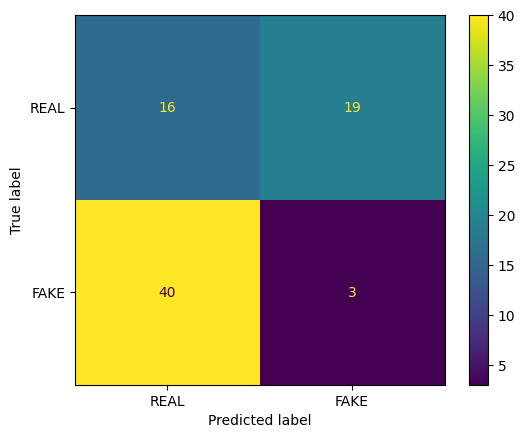

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(results_df["true_label"], results_df["verdict"], labels=["REAL", "FAKE"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["REAL", "FAKE"])
disp.plot()

In [ ]:
test_img_path = image_df["image_path"].iloc[0]
print(test_img_path)

/content/drive/MyDrive/Deepfake_Project/data/processed/frames/FAKE/kxhwssipyi/frame_60.jpg


In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

def make_gradcam_heatmap(img_path, model, last_conv_layer_name="Conv_1"):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = np.maximum(heatmap, 0)
    heatmap = heatmap / tf.reduce_max(heatmap)

    return heatmap.numpy()

In [ ]:
def display_gradcam(img_path, heatmap, alpha=0.4):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))

    heatmap = cv2.resize(heatmap, (224, 224))
    heatmap = np.uint8(255 * heatmap)

    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed_img = cv2.addWeighted(img, 1 - alpha, heatmap_color, alpha, 0)

    plt.figure(figsize=(8, 4))

    plt.subplot(1, 2, 1)
    plt.title("Original Frame")
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.title("Grad-CAM Heatmap")
    plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
    plt.axis("off")

    plt.show()

Expected: [['keras_tensor_159']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)

  heatmap = np.uint8(255 * heatmap)



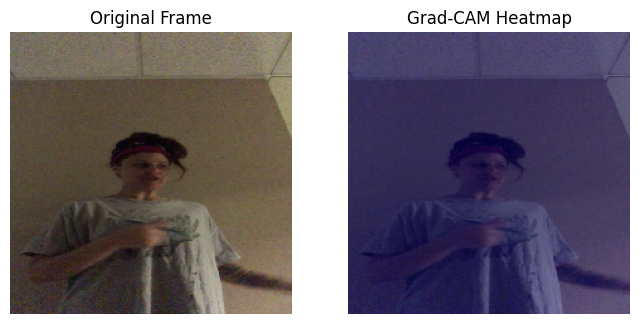

In [ ]:
heatmap = make_gradcam_heatmap(test_img_path, visual_model)
display_gradcam(test_img_path, heatmap)

In [ ]:
gradcam_path = os.path.join(EXPLAIN_DIR, "gradcam_sample.png")

heatmap = make_gradcam_heatmap(test_img_path, visual_model)

img = cv2.imread(test_img_path)
img = cv2.resize(img, (224, 224))

heatmap_resized = cv2.resize(heatmap, (224, 224))
heatmap_resized = np.uint8(255 * heatmap_resized)
heatmap_color = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)

superimposed_img = cv2.addWeighted(img, 0.6, heatmap_color, 0.4, 0)

cv2.imwrite(gradcam_path, superimposed_img)

print("Saved:", gradcam_path)

  heatmap_resized = np.uint8(255 * heatmap_resized)



Saved: /content/drive/MyDrive/Deepfake_Project/data/outputs/explainability/gradcam_sample.png


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(results_df["true_label"], results_df["verdict"]))

  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))

  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))

  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



              precision    recall  f1-score   support

        FAKE       0.14      0.04      0.06        80
        REAL       0.29      0.20      0.24        80
   UNCERTAIN       0.00      0.00      0.00         0

    accuracy                           0.12       160
   macro avg       0.14      0.08      0.10       160
weighted avg       0.21      0.12      0.15       160



In [ ]:
print(results_df["verdict"].value_counts())

verdict
UNCERTAIN    82
REAL         56
FAKE         22
Name: count, dtype: int64


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing import image

os.makedirs(EXPLAIN_DIR, exist_ok=True)

In [ ]:
def make_gradcam_heatmap(img_path, model, last_conv_layer_name="Conv_1"):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    grad_model = tf.keras.models.Model(
        model.inputs,
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = np.maximum(heatmap, 0)

    if tf.reduce_max(heatmap) != 0:
        heatmap = heatmap / tf.reduce_max(heatmap)

    return heatmap.numpy()

In [ ]:
def save_gradcam(img_path, save_path, model):
    heatmap = make_gradcam_heatmap(img_path, model)

    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))

    heatmap = cv2.resize(heatmap, (224, 224))
    heatmap = np.uint8(255 * heatmap)

    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed_img = cv2.addWeighted(img, 0.6, heatmap_color, 0.4, 0)

    cv2.imwrite(save_path, superimposed_img)

    return superimposed_img

In [ ]:
real_samples = image_df[image_df["label"] == "REAL"].sample(2, random_state=42)
fake_samples = image_df[image_df["label"] == "FAKE"].sample(2, random_state=42)

gradcam_samples = pd.concat([real_samples, fake_samples]).reset_index(drop=True)

saved_paths = []

for i, row in gradcam_samples.iterrows():
    img_path = row["image_path"]
    label = row["label"]

    save_path = os.path.join(EXPLAIN_DIR, f"gradcam_{label}_{i+1}.png")

    save_gradcam(img_path, save_path, visual_model)

    saved_paths.append(save_path)

    print("Saved:", save_path)

Expected: ['keras_tensor_159']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)



Saved: /content/drive/MyDrive/Deepfake_Project/data/outputs/explainability/gradcam_REAL_1.png
Saved: /content/drive/MyDrive/Deepfake_Project/data/outputs/explainability/gradcam_REAL_2.png
Saved: /content/drive/MyDrive/Deepfake_Project/data/outputs/explainability/gradcam_FAKE_3.png
Saved: /content/drive/MyDrive/Deepfake_Project/data/outputs/explainability/gradcam_FAKE_4.png


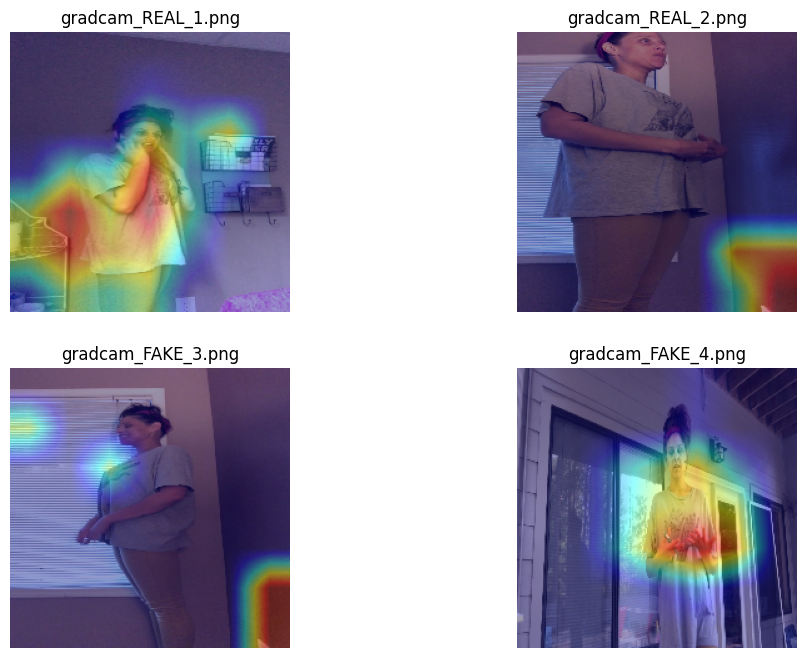

In [ ]:
plt.figure(figsize=(12, 8))

for i, path in enumerate(saved_paths):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 2, i + 1)
    plt.imshow(img)
    plt.title(os.path.basename(path))
    plt.axis("off")

plt.show()

In [ ]:
from moviepy.editor import VideoFileClip

for _, row in tqdm(sample_df.iterrows(), total=len(sample_df)):
    filename = row["filename"]
    label = row["label"]
    video_path = row["video_path"]

    out_dir = os.path.join(AUDIO_DIR, label)
    os.makedirs(out_dir, exist_ok=True)

    audio_path = os.path.join(out_dir, os.path.splitext(filename)[0] + ".wav")

    if os.path.exists(audio_path):
        continue

    try:
        clip = VideoFileClip(video_path)
        if clip.audio is not None:
            clip.audio.write_audiofile(audio_path, logger=None)
        clip.close()
    except Exception as e:
        print("Audio error:", filename, e)

print("Audio extraction finished.")

/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:294: SyntaxWarning: invalid escape sequence '\d'
  lines_video = [l for l in lines if ' Video: ' in l and re.search('\d+x\d+', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:367: SyntaxWarning: invalid escape sequence '\d'
  rotation_lines = [l for l in lines if 'rotate          :' in l and re.search('\d+$', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:370: SyntaxWarning: invalid escape sequence '\d'
  match = re.search('\d+$', rotation_line)
  if event.key is 'enter':

100%|██████████| 160/160 [00:00<00:00, 165.87it/s]

Audio extraction finished.


In [ ]:
text_rows = []

for _, row in sample_df.iterrows():
    text_rows.append({
        "filename": row["filename"],
        "transcript": "",
        "ocr_text": "",
        "claim_text": "",
        "text_score": 0.5
    })

text_df = pd.DataFrame(text_rows)
text_csv = os.path.join(TEXT_DIR, "text_features_placeholder.csv")
text_df.to_csv(text_csv, index=False)

print("Saved:", text_csv)

Saved: /content/drive/MyDrive/Deepfake_Project/data/processed/text/text_features_placeholder.csv
